In [0]:
# =========================================================
# Análise histórica: Ranking por período (2003–2023)
# Períodos alinhados ao início dos pontos corridos
# =========================================================

import matplotlib.pyplot as plt

query = """
WITH base AS (

    -- Mandante
    SELECT
        p.partida_id,
        p.mandante AS clube,
        p.mandante_placar AS gols_pro,
        p.visitante_placar AS gols_contra,
        YEAR(p.data_dt) AS ano
    FROM fato_partida p

    UNION ALL

    -- Visitante
    SELECT
        p.partida_id,
        p.visitante AS clube,
        p.visitante_placar AS gols_pro,
        p.mandante_placar AS gols_contra,
        YEAR(p.data_dt) AS ano
    FROM fato_partida p
),

periodos AS (
    SELECT
        clube,
        ano,
        CASE
            WHEN ano BETWEEN 2003 AND 2009 THEN '2003-2009'
            WHEN ano BETWEEN 2010 AND 2019 THEN '2010-2019'
            WHEN ano BETWEEN 2020 AND 2023 THEN '2020-2023'
        END AS periodo,
        CASE
            WHEN gols_pro > gols_contra THEN 3
            WHEN gols_pro = gols_contra THEN 1
            ELSE 0
        END AS pontos
    FROM base
),

metricas AS (
    SELECT
        clube,
        periodo,
        COUNT(*) AS jogos,
        COUNT(DISTINCT ano) AS temporadas_disputadas,
        SUM(pontos) AS pontos
    FROM periodos
    GROUP BY clube, periodo
)

SELECT
    clube,
    periodo,
    jogos,
    temporadas_disputadas,
    pontos,
    ROUND(CAST(pontos AS DOUBLE) / CAST(jogos AS DOUBLE), 3) AS ppg,
    ROUND(CAST(pontos AS DOUBLE) / CAST(temporadas_disputadas AS DOUBLE), 1) AS pontos_por_temporada
FROM metricas
ORDER BY periodo, pontos DESC
"""

# Executa a consulta
df_resultado = spark.sql(query)

# Exibe tabela final (fica salva no .ipynb)
display(df_resultado)

clube,periodo,jogos,temporadas_disputadas,pontos,ppg,pontos_por_temporada
Sao Paulo,2003-2009,286,7,513,1.794,73.3
Cruzeiro,2003-2009,286,7,458,1.601,65.4
Internacional,2003-2009,286,7,457,1.598,65.3
Santos,2003-2009,286,7,455,1.591,65.0
Goias,2003-2009,286,7,419,1.465,59.9
Flamengo,2003-2009,286,7,419,1.465,59.9
Athletico-pr,2003-2009,286,7,403,1.409,57.6
Fluminense,2003-2009,286,7,382,1.336,54.6
Palmeiras,2003-2009,240,6,378,1.575,63.0
Corinthians,2003-2009,248,6,361,1.456,60.2


In [0]:
# =========================================================
# Análise: Desempenho geral dos clubes (2003–2023)
# Dimensão temporal explícita
# =========================================================

query = """
WITH resultados AS (

    -- Mandante
    SELECT 
        p.partida_id,
        p.mandante AS clube,
        p.mandante_placar AS gols_pro,
        p.visitante_placar AS gols_contra,
        YEAR(p.data_dt) AS ano
    FROM fato_partida p
    WHERE YEAR(p.data_dt) BETWEEN 2003 AND 2023

    UNION ALL

    -- Visitante
    SELECT
        p.partida_id,
        p.visitante AS clube,
        p.visitante_placar AS gols_pro,
        p.mandante_placar AS gols_contra,
        YEAR(p.data_dt) AS ano
    FROM fato_partida p
    WHERE YEAR(p.data_dt) BETWEEN 2003 AND 2023
),

metricas AS (
    SELECT
        clube,
        COUNT(*) AS jogos,
        COUNT(DISTINCT ano) AS temporadas_disputadas,
        SUM(CASE WHEN gols_pro > gols_contra THEN 1 ELSE 0 END) AS vitorias,
        SUM(CASE WHEN gols_pro = gols_contra THEN 1 ELSE 0 END) AS empates,
        SUM(CASE WHEN gols_pro < gols_contra THEN 1 ELSE 0 END) AS derrotas,
        SUM(gols_pro - gols_contra) AS saldo_gols,
        SUM(
            CASE 
                WHEN gols_pro > gols_contra THEN 3
                WHEN gols_pro = gols_contra THEN 1
                ELSE 0
            END
        ) AS pontos
    FROM resultados
    GROUP BY clube
)

SELECT
    clube,
    jogos,
    temporadas_disputadas,
    vitorias,
    empates,
    derrotas,
    saldo_gols,
    pontos,
    ROUND(CAST(pontos AS DOUBLE) / CAST(jogos AS DOUBLE), 3) AS ppg,
    ROUND(
        CAST(pontos AS DOUBLE) / CAST(jogos * 3 AS DOUBLE) * 100,
        2
    ) AS aproveitamento_pct
FROM metricas
ORDER BY
    pontos DESC,
    aproveitamento_pct DESC,
    saldo_gols DESC
"""

# Executa a consulta
df_resultado = spark.sql(query)

# Exibe tabela final (fica salva no .ipynb)
display(df_resultado)

clube,jogos,temporadas_disputadas,vitorias,empates,derrotas,saldo_gols,pontos,ppg,aproveitamento_pct
Sao Paulo,818,21,365,229,224,284,1324,1.619,53.95
Flamengo,818,21,354,221,243,207,1283,1.568,52.28
Santos,818,21,340,217,261,196,1237,1.512,50.41
Internacional,780,20,339,202,239,189,1219,1.563,52.09
Corinthians,780,20,326,229,225,167,1207,1.547,51.58
Atletico-mg,779,20,327,199,253,153,1180,1.515,50.49
Fluminense,818,21,322,213,283,66,1179,1.441,48.04
Palmeiras,734,19,329,190,215,237,1177,1.604,53.45
Gremio,738,19,316,185,237,185,1133,1.535,51.17
Athletico-pr,780,20,309,189,282,67,1116,1.431,47.69


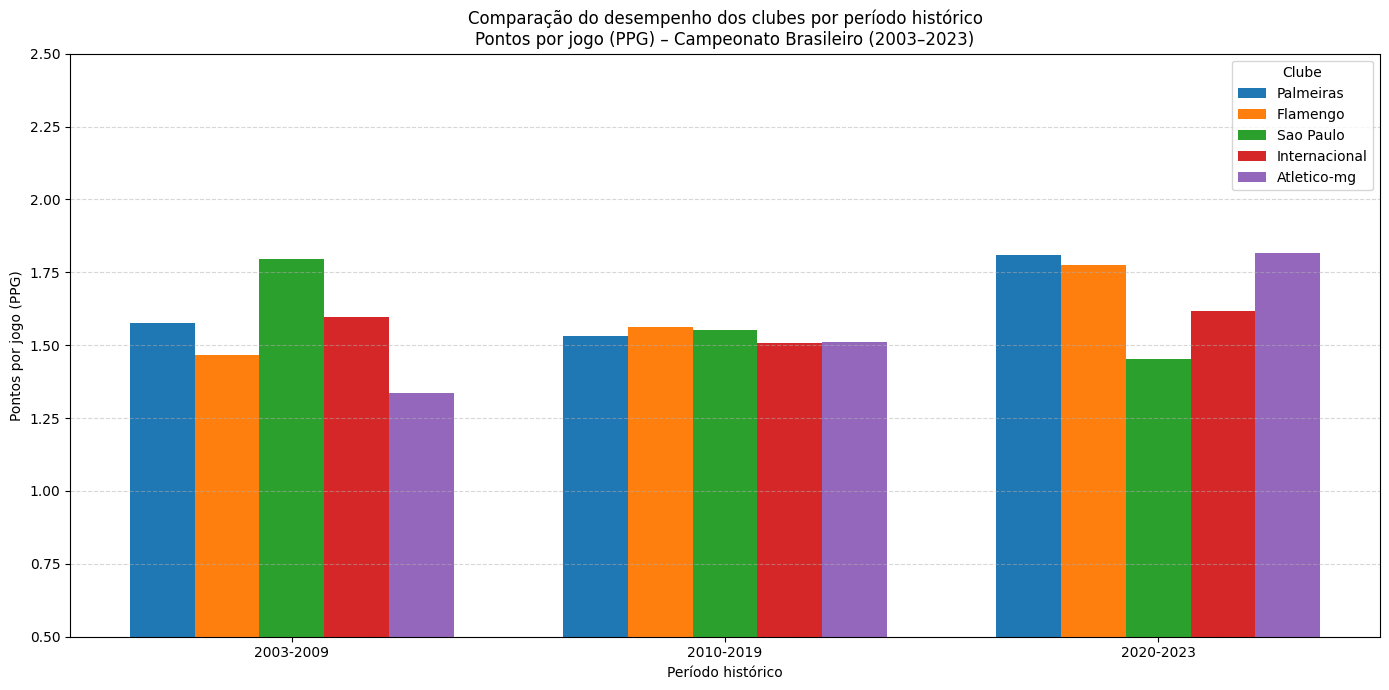

In [0]:
# ---------------------------------------------------------
# Gráfico em barras
# Pontos por jogo (PPG) por período histórico
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pdf = df_resultado.toPandas()

# Ordem correta dos períodos
ordem_periodos = ["2003-2009", "2010-2019", "2020-2023"]
pdf["periodo"] = pd.Categorical(
    pdf["periodo"],
    categories=ordem_periodos,
    ordered=True
)

# Seleciona os 5 clubes com maior PPG médio no período total
top_clubes = (
    pdf.groupby("clube", as_index=False)["ppg"]
       .mean()
       .sort_values("ppg", ascending=False)
       .head(5)["clube"]
       .tolist()
)

pdf_plot = pdf[pdf["clube"].isin(top_clubes)].sort_values("periodo")

# Preparação para barras agrupadas
periodos = ordem_periodos
x = np.arange(len(periodos))
largura = 0.15

plt.figure(figsize=(14, 7))

for i, clube in enumerate(top_clubes):
    valores = (
        pdf_plot[pdf_plot["clube"] == clube]
        .set_index("periodo")
        .reindex(periodos)["ppg"]
        .values
    )
    plt.bar(x + i * largura, valores, largura, label=clube)

plt.xlabel("Período histórico")
plt.ylabel("Pontos por jogo (PPG)")
plt.title(
    "Comparação do desempenho dos clubes por período histórico\n"
    "Pontos por jogo (PPG) – Campeonato Brasileiro (2003–2023)"
)
plt.xticks(x + largura * (len(top_clubes) - 1) / 2, periodos)
plt.ylim(0.5, 2.5)
plt.legend(title="Clube")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
